Loading required package: NbClust

Warning message in cor(numData, use = "pairwise.complete.obs"):
"the standard deviation is zero"
Warning message in cmdscale(ddata, k = mds_k, eig = TRUE):
"only 236 of the first 250 eigenvalues are > 0"



=== Index: silhouette ===
Best.nc = 100 
Saved plot: silhouette_AllIndex_FP.pdf 
Saved assignment: silhouette_DataGrp_FP.csv 
Saved scatter: silhouette_MDS12_scatter_FP.pdf 

=== Index: dunn ===
Best.nc = 27 
Saved plot: dunn_AllIndex_FP.pdf 
Saved assignment: dunn_DataGrp_FP.csv 
Saved scatter: dunn_MDS12_scatter_FP.pdf 

=== Index: gap ===
Best.nc = 2 
Saved plot: gap_AllIndex_FP.pdf 
Saved assignment: gap_DataGrp_FP.csv 
Saved scatter: gap_MDS12_scatter_FP.pdf 

=== Index: ch ===
Best.nc = 5 
Saved plot: ch_AllIndex_FP.pdf 
Saved assignment: ch_DataGrp_FP.csv 
Saved scatter: ch_MDS12_scatter_FP.pdf 

=== Index: db ===
Best.nc = 100 
Saved plot: db_AllIndex_FP.pdf 
Saved assignment: db_DataGrp_FP.csv 
Saved scatter: db_MDS12_scatter_FP.pdf 

=== Index: ptbiserial ===
Best.nc = 6 
Saved plot: ptbiserial_AllIndex_FP.pdf 
Saved assignment: ptbiserial_DataGrp_FP.csv 
Saved scatter: ptbiserial_MDS12_scatter_FP.pdf 

<U+2705> Completed all indices.


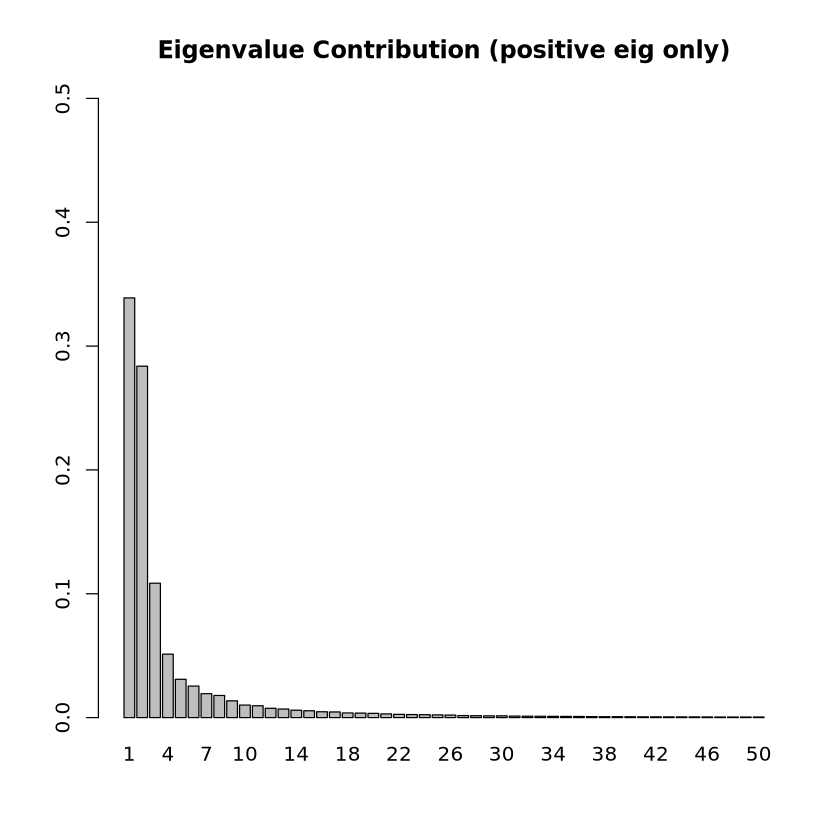

In [1]:
# --- 必要パッケージ ---
if (!require(NbClust)) { install.packages("NbClust"); library(NbClust) }

# --- 入力 ---
set.seed(42)  # 再現性
ifname <- "preprocessed_features_FP.csv"

# --- データ読み込み ---
readData <- read.delim(ifname, header = TRUE, sep = ",", row.names = 1,
                       as.is = TRUE, strip.white = FALSE)

# --- 数値列のみ抽出 ---
nf1 <- ncol(readData)
charaCheck <- rep(FALSE, nf1)
for (i in 1:nf1) {
  charaCheck[i] <- !is.character(readData[, i])
}
numData <- readData[, charaCheck, drop = FALSE]

# --- 相関 -> 距離 -> 線形MDS ---
#   ※ 元の流儀を踏襲（NA→0、1 - cor で距離を作って dist()）
corData <- cor(numData, use = "pairwise.complete.obs")
corData[is.na(corData)] <- 0
ddata <- dist(1 - corData)

NF <- ncol(corData)
mds_k <- min(300, max(1, NF - 1))
mdsdata <- cmdscale(ddata, k = mds_k, eig = TRUE)

# --- 固有値の寄与（参考：正の固有値のみで計算） ---
all_eig <- mdsdata$eig
pos_eig <- all_eig[all_eig > 0]
if (length(pos_eig) > 0) {
  peigen <- pos_eig / sum(pos_eig)
} else {
  peigen <- numeric(0)
}

# 画面に棒グラフ（上位50）を出す（必要なら保存に変更可）
if (length(peigen) > 0) {
  max_dim <- min(50, length(peigen))
  barplot(peigen[1:max_dim], names.arg = 1:max_dim, ylim = c(0, 0.5),
          main = "Eigenvalue Contribution (positive eig only)")
}

# --- 2次元散布（第1-2軸、クラスタ塗り分けは後で） ---
xaxis <- 1; yaxis <- 2
par(mfrow = c(1, 1)); par(cex = 1)

# --- NbClust を指標ごとにループ実行 ---
index_list <- c("silhouette", "dunn", "gap", "ch", "db", "ptbiserial")

# 出力の共通接頭辞（必要に応じて日付など付けてもOK）
suffix <- "_FP"

for (cindex in index_list) {
  cat("\n=== Index:", cindex, "===\n")
  # NbClust 実行
  clustEst <- tryCatch({
    NbClust(
      data = mdsdata$points,
      diss = NULL,
      distance = "euclidean",
      min.nc = 2,
      max.nc = 100,
      method = "ward.D2",
      index = cindex
    )
  }, error = function(e) {
    warning(paste("Index", cindex, "failed:", e$message))
    return(NULL)
  })

  if (is.null(clustEst)) next

  # ベスト結果
  best_nc <- clustEst$Best.nc[1]
  classData <- clustEst$Best.partition
  grpname <- as.factor(classData)

  cat("Best.nc =", best_nc, "\n")

  # --- 評価曲線の図を保存 ---
  plot_file <- paste0(cindex, "_AllIndex", suffix, ".pdf")
  pdf(plot_file, width = 7, height = 5)
  plot(clustEst$All.index, type = "b", main = paste0("Index: ", cindex),
       xlab = "k", ylab = "Index value")
  grid()
  dev.off()
  cat("Saved plot:", plot_file, "\n")

  # --- クラスタ割当のCSV出力（手法名ごとにファイル名を変更） ---
  #     例）silhouette_DataGrp_OH.csv
  fn_assign <- paste0(cindex, "_DataGrp", suffix, ".csv")
  write.csv(grpname, file = fn_assign)
  cat("Saved assignment:", fn_assign, "\n")

  # --- 2次元プロットをクラスタ色で保存（任意） ---
  scat_file <- paste0(cindex, "_MDS12_scatter", suffix, ".pdf")
  pdf(scat_file, width = 6, height = 6)
  maxiv <- max(c(mdsdata$points[, xaxis], mdsdata$points[, yaxis]))
  miniv <- min(c(mdsdata$points[, xaxis], mdsdata$points[, yaxis]))
  ivdata <- c(as.integer(miniv) - 1, as.integer(maxiv) + 1)
  plot(mdsdata$points[, xaxis], mdsdata$points[, yaxis],
       col = grpname, pch = 19, cex = 0.8, xlim = ivdata, ylim = ivdata,
       main = paste0("MDS (", cindex, ", k=", best_nc, ")"),
       xlab = paste0("Dim ", xaxis), ylab = paste0("Dim ", yaxis))
  # ※ ラベルは点が多いと読みにくいのでコメントアウト
  # text(mdsdata$points[, xaxis], mdsdata$points[, yaxis], labels = grpname, cex = 0.6, pos = 3)
  dev.off()
  cat("Saved scatter:", scat_file, "\n")
}

cat("\n✅ Completed all indices.\n")


In [4]:
# --- 必要パッケージ ---
if (!require(NbClust)) { install.packages("NbClust"); library(NbClust) }
if (!require(ggplot2)) { install.packages("ggplot2"); library(ggplot2) }
if (!require(ggrepel)) { install.packages("ggrepel"); library(ggrepel) }
if (!require(scales))  { install.packages("scales");  library(scales) }
if (!require(MASS))    { install.packages("MASS");    library(MASS) }     # isoMDS 用（必要なら）
if (!require(mclust))  { install.packages("mclust");  library(mclust) }   # ARI

# --- 入力 ---
set.seed(42)  # 再現性
ifname <- "preprocessed_features_FP.csv"

# --- 出力設定（OH/FP 切替は suffix を変更） ---
suffix     <- "_FP"                               # ← "_FP" に変えるだけでFP版
suffix_tag <- sub("^_", "", suffix)               # "OH" など
out_dir    <- paste0("figs_", suffix_tag)         # 例: figs_OH
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)
ts_tag     <- format(Sys.time(), "%Y%m%d_%H%M")

# --- データ読み込み ---
readData <- read.delim(ifname, header = TRUE, sep = ",", row.names = 1,
                       as.is = TRUE, strip.white = FALSE)

# --- 数値列のみ抽出 ---
is_num <- vapply(readData, function(x) !is.character(x), logical(1))
numData <- readData[, is_num, drop = FALSE]

# --- 相関 -> 距離 -> 古典MDS ---
#   ※ 元コード準拠（NA→0、1 - cor）
corData <- cor(numData, use = "pairwise.complete.obs")
corData[is.na(corData)] <- 0
ddata <- dist(1 - corData)

NF <- ncol(corData)
mds_k <- min(300, max(1, NF - 1))
mdsdata <- cmdscale(ddata, k = mds_k, eig = TRUE)

# --- 固有値寄与（全基準＆正の固有値基準） + CSV保存 ---
pct <- function(x) sprintf("%.2f%%", 100 * x)

eig_all <- mdsdata$eig
S_all   <- sum(eig_all)
share_all <- eig_all / S_all

eig_pos <- eig_all[eig_all > 0]
S_pos   <- sum(eig_pos)
share_pos <- rep(NA_real_, length(eig_all))
share_pos[eig_all > 0] <- eig_all[eig_all > 0] / S_pos

cum_all <- cumsum(share_all)
cum_pos <- {
  tmp <- share_pos; tmp[is.na(tmp)] <- 0; cumsum(tmp)
}

# 第1〜3軸のレポート（全基準）
p1_all <- share_all[1]; p2_all <- share_all[2]
cum3_all <- sum(share_all[1:min(3, length(share_all))], na.rm = TRUE)
cat("【全固有値基準】第1:", pct(p1_all), "  第2:", pct(p2_all),
    "  1–2合計:", pct(p1_all + p2_all), "  1–3累積:", pct(cum3_all), "\n")

# CSV出力（寄与一覧）
df_eig_out <- data.frame(
  Dim           = seq_along(eig_all),
  Eigenvalue    = eig_all,
  Share_all     = share_all,
  Share_pos     = share_pos,
  CumShare_all  = cum_all,
  CumShare_pos  = cum_pos
)
write.csv(df_eig_out, file.path(out_dir, paste0("MDS_eigen_contributions_", suffix_tag, "_", ts_tag, ".csv")),
          row.names = FALSE)

# ====== “全体で1回” のスタイリッシュ図（スクリープロット & Top50） ======
if (length(eig_pos) > 0) {
  df_eig <- data.frame(
    Dim  = seq_along(eig_pos),
    Eig  = as.numeric(eig_pos)
  )
  df_eig$Prop <- df_eig$Eig / sum(df_eig$Eig)
  df_eig$Cum  <- cumsum(df_eig$Prop)

  # 1) スクリープロット（棒 + 累積線）
  p_scree <- ggplot(df_eig, aes(x = Dim, y = Prop)) +
    geom_col(width = 0.85, alpha = 0.9) +
    geom_line(aes(y = Cum), linewidth = 1.1) +
    geom_point(aes(y = Cum), size = 2) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1),
                       sec.axis = sec_axis(~ ., name = "Cumulative share")) +
    labs(title = "Scree plot (positive eigenvalues only)",
         subtitle = paste0("Classical MDS  |  ", suffix_tag),
         x = "Dimension", y = "Variance share") +
    theme_minimal(base_size = 12) +
    theme(panel.grid.minor = element_blank(),
          axis.title = element_text(face = "bold"),
          plot.title = element_text(face = "bold"))
  ggsave(file.path(out_dir, paste0("MDS_scree_", suffix_tag, "_", ts_tag, ".png")),
         p_scree, width = 7, height = 5, dpi = 300)
  ggsave(file.path(out_dir, paste0("MDS_scree_", suffix_tag, "_", ts_tag, ".pdf")),
         p_scree, width = 7, height = 5, device = cairo_pdf)

  # 2) 固有値トップ50の棒グラフ
  topN <- min(50, nrow(df_eig))
  df_eig50 <- df_eig[1:topN, , drop = FALSE]
  p_bar50 <- ggplot(df_eig50, aes(x = Dim, y = Prop)) +
    geom_col(width = 0.85, alpha = 0.95) +
    labs(title = paste0("Top-", topN, " eigenvalue shares"),
         subtitle = paste0("Classical MDS  |  ", suffix_tag),
         x = "Dimension", y = "Variance share") +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
    theme_minimal(base_size = 12) +
    theme(panel.grid.minor = element_blank(),
          axis.title = element_text(face = "bold"),
          plot.title = element_text(face = "bold"))
  ggsave(file.path(out_dir, paste0("MDS_bar_top", topN, "_", suffix_tag, "_", ts_tag, ".png")),
         p_bar50, width = 7, height = 5, dpi = 300)
  ggsave(file.path(out_dir, paste0("MDS_bar_top", topN, "_", suffix_tag, "_", ts_tag, ".pdf")),
         p_bar50, width = 7, height = 5, device = cairo_pdf)
} else {
  warning("No positive eigenvalues; scree/top50 plots skipped.")
}

# ====== NbClust：指標ごと ======
index_list <- c("silhouette", "dunn", "gap", "ch", "db", "ptbiserial")

for (cindex in index_list) {
  cat("\n=== Index:", cindex, "===\n")
  clustEst <- tryCatch({
    NbClust(
      data = mdsdata$points, diss = NULL, distance = "euclidean",
      min.nc = 2, max.nc = 100, method = "ward.D2", index = cindex
    )
  }, error = function(e) { warning(paste("Index", cindex, "failed:", e$message)); NULL })
  if (is.null(clustEst)) next

  best_nc  <- clustEst$Best.nc[1]
  grpname  <- as.factor(clustEst$Best.partition)
  cat("Best.nc =", best_nc, "\n")

  # 割当CSV
  fn_assign <- paste0(cindex, "_DataGrp", suffix, ".csv")
  write.csv(grpname, file = file.path(out_dir, fn_assign))

  # (a) MDS 1-2 散布図（楕円つき）
  df_plot <- data.frame(
    MDS1    = mdsdata$points[, 1],
    MDS2    = mdsdata$points[, 2],
    Cluster = grpname,
    ID      = rownames(mdsdata$points)
  )
  rng <- range(c(df_plot$MDS1, df_plot$MDS2), na.rm = TRUE)
  pad <- diff(rng) * 0.05; lims <- c(min(rng) - pad, max(rng) + pad)

  p_scatter <- ggplot(df_plot, aes(x = MDS1, y = MDS2, color = Cluster)) +
    stat_ellipse(aes(group = Cluster), type = "norm", level = 0.95,
                 linewidth = 0.6, alpha = 0.25) +
    geom_point(size = 2.2, alpha = 0.8) +
    # ggrepel::geom_text_repel(aes(label = ID), size = 3, max.overlaps = 100,
    #                          box.padding = 0.3, point.padding = 0.2, show.legend = FALSE) +
    coord_equal(xlim = lims, ylim = lims, expand = TRUE) +
    scale_color_hue(h = c(0, 360), l = 55, c = 90) +
    labs(title = "MDS (Dim1 vs Dim2) — Ward.D2 × NbClust",
         subtitle = paste0("Index: ", cindex, "  |  Best k = ", best_nc, "  |  ", suffix_tag),
         x = "MDS Dimension 1", y = "MDS Dimension 2", color = "Cluster") +
    theme_minimal(base_size = 12) +
    theme(panel.grid.major = element_line(linewidth = 0.3, linetype = "dashed"),
          panel.grid.minor = element_blank(),
          axis.title = element_text(face = "bold"),
          plot.title = element_text(face = "bold", size = 14, margin = margin(b = 4)),
          plot.subtitle = element_text(size = 11, colour = "grey30"),
          legend.position = "right",
          legend.title = element_text(face = "bold"))
  ggsave(file.path(out_dir, paste0("MDS12_scatter_", cindex, "_", suffix_tag, "_", ts_tag, ".png")),
         p_scatter, width = 7, height = 6, dpi = 300)
  ggsave(file.path(out_dir, paste0("MDS12_scatter_", cindex, "_", suffix_tag, "_", ts_tag, ".pdf")),
         p_scatter, width = 7, height = 6, device = cairo_pdf)

  # (b) NbClust All.index 曲線
  if (!is.null(clustEst$All.index)) {
    idx_vals  <- as.numeric(clustEst$All.index)
    k_labels  <- names(clustEst$All.index)
    k_seq <- if (is.null(k_labels) || any(k_labels == "")) seq_along(idx_vals) else suppressWarnings(as.numeric(k_labels))
    if (any(is.na(k_seq))) k_seq <- seq_along(idx_vals)

    df_idx <- data.frame(k = k_seq, value = idx_vals)
    p_idx <- ggplot(df_idx, aes(x = k, y = value)) +
      geom_line(linewidth = 1) +
      geom_point(size = 2) +
      labs(title = paste0("NbClust All.index — ", cindex),
           subtitle = paste0("Ward.D2 / Euclidean  |  ", suffix_tag),
           x = "k", y = "Index value") +
      theme_minimal(base_size = 12) +
      theme(panel.grid.minor = element_blank(),
            axis.title = element_text(face = "bold"),
            plot.title = element_text(face = "bold"))
    ggsave(file.path(out_dir, paste0("NbClust_AllIndex_", cindex, "_", suffix_tag, "_", ts_tag, ".png")),
           p_idx, width = 7, height = 5, dpi = 300)
    ggsave(file.path(out_dir, paste0("NbClust_AllIndex_", cindex, "_", suffix_tag, "_", ts_tag, ".pdf")),
           p_idx, width = 7, height = 5, device = cairo_pdf)
  }

  # (c) クラスタサイズ棒グラフ
  df_size <- as.data.frame(table(Cluster = grpname))
  p_size <- ggplot(df_size, aes(x = Cluster, y = Freq, fill = Cluster)) +
    geom_col(width = 0.7, alpha = 0.9, show.legend = FALSE) +
    geom_text(aes(label = Freq), vjust = -0.3, size = 3.6) +
    labs(title = "Cluster sizes",
         subtitle = paste0("Assignment by NbClust best k  |  ", suffix_tag),
         x = "Cluster", y = "Count") +
    theme_minimal(base_size = 12) +
    theme(panel.grid.minor = element_blank(),
          axis.title = element_text(face = "bold"),
          plot.title = element_text(face = "bold"))
  ggsave(file.path(out_dir, paste0("Cluster_sizes_", cindex, "_", suffix_tag, "_", ts_tag, ".png")),
         p_size, width = 6.5, height = 5, dpi = 300)
  ggsave(file.path(out_dir, paste0("Cluster_sizes_", cindex, "_", suffix_tag, "_", ts_tag, ".pdf")),
         p_size, width = 6.5, height = 5, device = cairo_pdf)

  cat("Saved: ", cindex, " figures & assignment under ", normalizePath(out_dir), "\n")
}

# ====== top3 vs cumeig（≥0.8）の両条件でクラスタリングし、ARIを計算 ======
eigtarget <- 0.80
contrib_pos <- if (length(eig_pos) > 0) eig_pos / sum(eig_pos) else numeric(0)
k_cumeig <- if (length(contrib_pos) > 0) which(cumsum(contrib_pos) >= eigtarget)[1] else 3
if (is.na(k_cumeig) || k_cumeig < 2) k_cumeig <- 3

coords_list <- list(
  top3   = mdsdata$points[, 1:min(3, ncol(mdsdata$points)), drop = FALSE],
  cumeig = mdsdata$points[, 1:min(k_cumeig, ncol(mdsdata$points)), drop = FALSE]
)

# 座標CSV（条件ごと）保存
for (cond in names(coords_list)) {
  write.csv(coords_list[[cond]],
            file.path(out_dir, paste0("MDScoords_", cond, "_", suffix_tag, "_", ts_tag, ".csv")))
}

index_list <- c("silhouette", "dunn", "gap", "ch", "db", "ptbiserial")
assignments <- list()

for (cond in names(coords_list)) {
  X <- coords_list[[cond]]
  rownames(X) <- rownames(mdsdata$points)

  for (cindex in index_list) {
    clustEst <- tryCatch({
      NbClust(data = X, diss = NULL, distance = "euclidean",
              min.nc = 2, max.nc = 100, method = "ward.D2", index = cindex)
    }, error = function(e) { warning(paste("failed:", cond, cindex, e$message)); NULL })
    if (is.null(clustEst)) next

    grp <- as.factor(clustEst$Best.partition)

    # 割当て保存
    fn_assign2 <- paste0("ClusterAssign_", cond, "_", cindex, "_",
                         suffix_tag, "_", ts_tag, ".csv")
    write.csv(data.frame(Variable = names(grp), Cluster = grp),
              file.path(out_dir, fn_assign2), row.names = FALSE)

    assignments[[paste(cond, cindex, sep = "_")]] <- grp
  }
}

# ARI: top3 と cumeig の一致度
ari_rows <- lapply(index_list, function(ix) {
  a <- assignments[[paste0("top3_", ix)]]
  b <- assignments[[paste0("cumeig_", ix)]]
  ari <- if (!is.null(a) && !is.null(b)) mclust::adjustedRandIndex(a, b) else NA_real_
  data.frame(Index = ix, ARI_top3_vs_cumeig = ari)
})
df_ari <- do.call(rbind, ari_rows)
write.csv(df_ari, file.path(out_dir, paste0("ARI_top3_vs_cumeig_", suffix_tag, "_", ts_tag, ".csv")),
          row.names = FALSE)
print(df_ari)

cat("\n✅ All done. Outputs under: ", normalizePath(out_dir), "\n")


Warning message in cor(numData, use = "pairwise.complete.obs"):
"the standard deviation is zero"
Warning message in cmdscale(ddata, k = mds_k, eig = TRUE):
"only 233 of the first 250 eigenvalues are > 0"


<U+3010><U+5168><U+56FA><U+6709><U+5024><U+57FA><U+6E96><U+3011><U+7B2C>1: 33.89%   <U+7B2C>2: 28.38%   1<U+2013>2<U+5408><U+8A08>: 62.27%   1<U+2013>3<U+7D2F><U+7A4D>: 73.12% 

=== Index: silhouette ===
Best.nc = 100 


Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calcula

Saved:  silhouette  figures & assignment under  /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_FP 

=== Index: dunn ===
Best.nc = 27 


Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Warning message:
"Removed 3 rows containing missing values or values outside the scale range
(`geom_path()`)."
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Warning message:
"Removed 3 rows containing missing values or values outside the scale range
(`geom_path()`)."


Saved:  dunn  figures & assignment under  /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_FP 

=== Index: gap ===
Best.nc = 2 
Saved:  gap  figures & assignment under  /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_FP 

=== Index: ch ===
Best.nc = 5 
Saved:  ch  figures & assignment under  /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_FP 

=== Index: db ===
Best.nc = 100 


Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calcula

Saved:  db  figures & assignment under  /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_FP 

=== Index: ptbiserial ===
Best.nc = 6 
Saved:  ptbiserial  figures & assignment under  /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_FP 
       Index ARI_top3_vs_cumeig
1 silhouette          0.7269810
2       dunn          0.6659305
3        gap          1.0000000
4         ch          0.7316243
5         db          0.7316243
6 ptbiserial          0.8081430

<U+2705> All done. Outputs under:  /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_FP 
